<a href="https://colab.research.google.com/github/varun0852/for-study/blob/master/Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
churn = pd.read_csv("Dataset/Bank Customer Churn Prediction.csv")
churn

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
churn['churn'].value_counts()

0    7963
1    2037
Name: churn, dtype: int64

In [ ]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
for i in churn.columns:
    print(set(churn[i]))
    print("\n\n")

{15695872, 15794178, 15794187, 15630349, 15597591, 15630363, 15794204, 15728669, 15663134, 15597602, 15597610, 15728683, 15761453, 15728693, 15663161, 15663164, 15695932, 15794236, 15663168, 15630402, 15728706, 15761477, 15728709, 15794253, 15630413, 15761487, 15794257, 15630419, 15761497, 15794266, 15663194, 15794273, 15761506, 15794276, 15794278, 15761525, 15794297, 15663234, 15630466, 15728773, 15597709, 15663249, 15761554, 15794323, 15663252, 15663263, 15794345, 15597739, 15630511, 15696047, 15794356, 15696054, 15728823, 15794360, 15696061, 15663294, 15728829, 15761600, 15728838, 15761606, 15663312, 15630551, 15794396, 15696098, 15794413, 15794414, 15630580, 15728885, 15761654, 15696120, 15630592, 15761670, 15728906, 15696141, 15728912, 15728917, 15630617, 15663386, 15761692, 15794468, 15794472, 15761706, 15794479, 15696175, 15761713, 15663410, 15630641, 15761717, 15761720, 15794493, 15663421, 15597885, 15728963, 15630661, 15761733, 15597896, 15597901, 15663438, 15663441, 15597909,

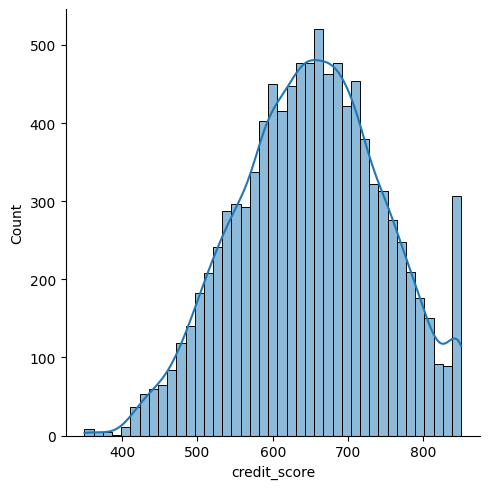

In [ ]:
sns.displot(data = churn['credit_score'], kde=True)

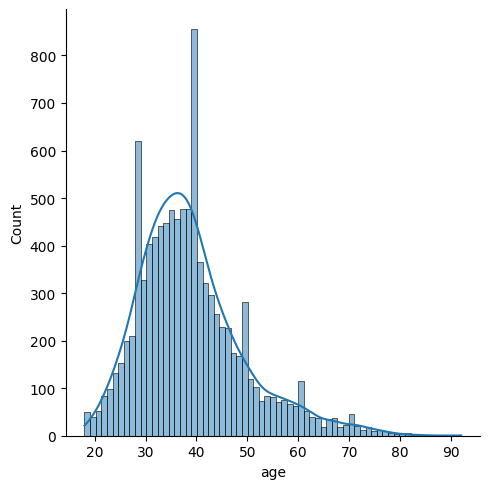

In [ ]:
sns.displot(data = churn['age'], kde=True)

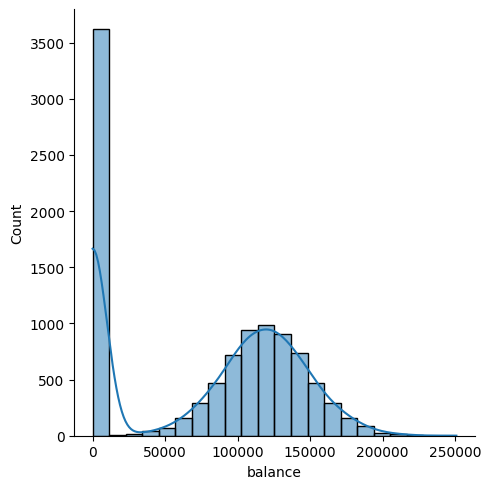

In [ ]:
sns.displot(data = churn['balance'], kde=True)

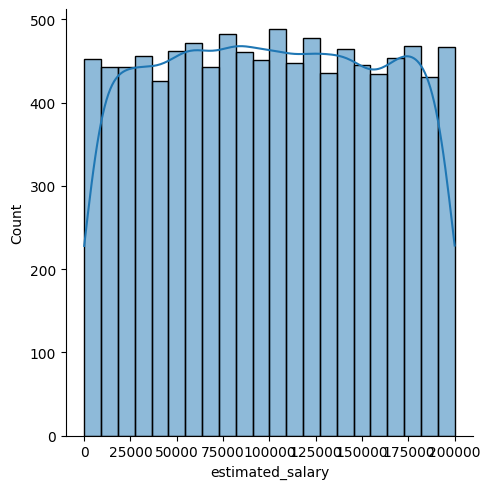

In [ ]:
sns.displot(data = churn['estimated_salary'], kde=True)

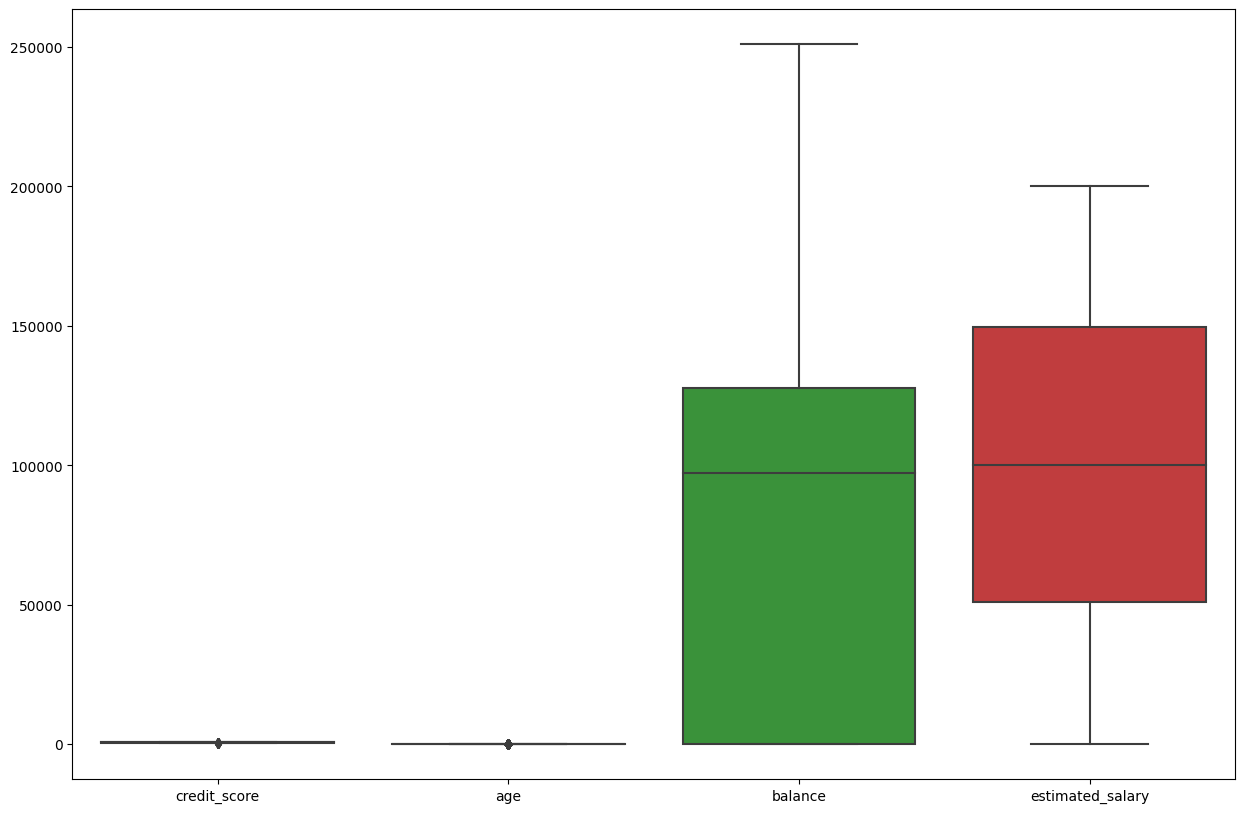

In [ ]:
churn_continuous = churn[["credit_score", "age", "balance", "estimated_salary"]]


plt.figure(figsize=(15,10))
sns.boxplot(data = churn_continuous)
plt.show()

In [ ]:
churn.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

<Axes: xlabel='country', ylabel='count'>

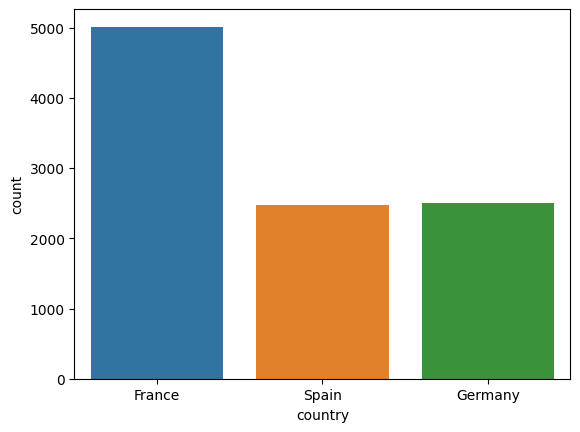

In [ ]:
sns.countplot(x = "country", data = churn)

<Axes: xlabel='gender', ylabel='count'>

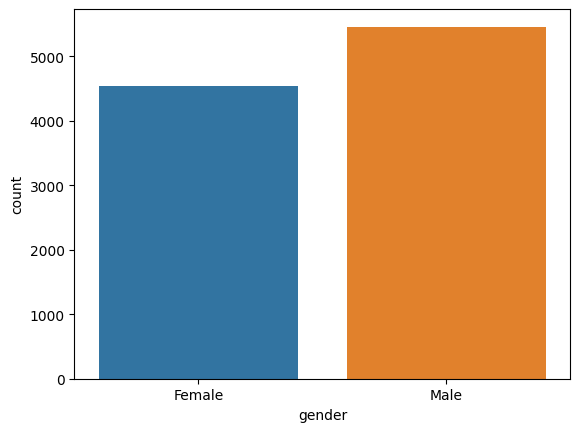

In [ ]:
sns.countplot(x = "gender", data = churn)

<Axes: xlabel='tenure', ylabel='count'>

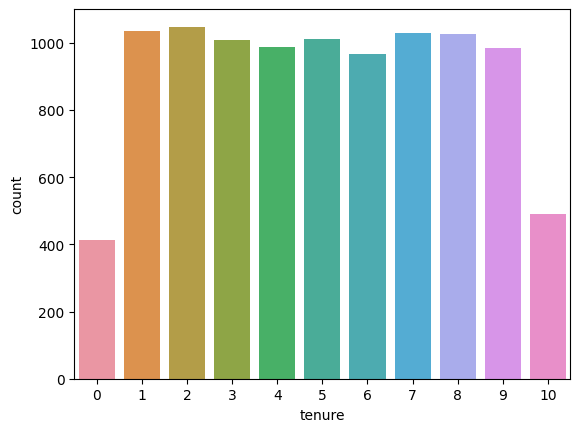

In [ ]:
sns.countplot(x = "tenure", data = churn)

<Axes: xlabel='products_number', ylabel='count'>

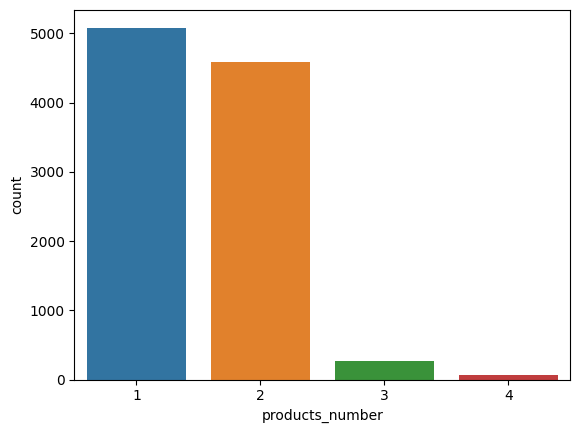

In [ ]:
sns.countplot(x = "products_number", data = churn)

<Axes: xlabel='credit_card', ylabel='count'>

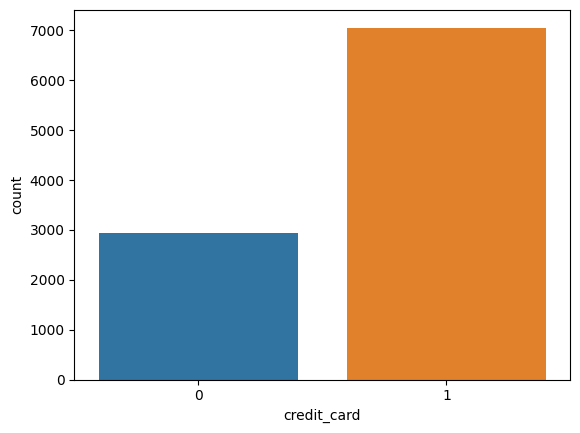

In [ ]:
sns.countplot(x = "credit_card", data = churn)

<Axes: xlabel='active_member', ylabel='count'>

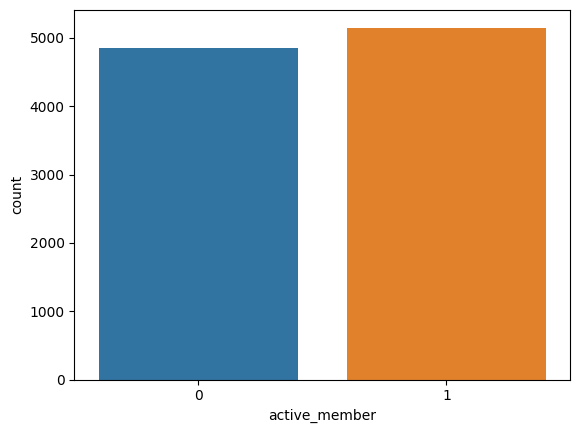

In [ ]:
sns.countplot(x = "active_member", data = churn)

<Axes: xlabel='churn', ylabel='count'>

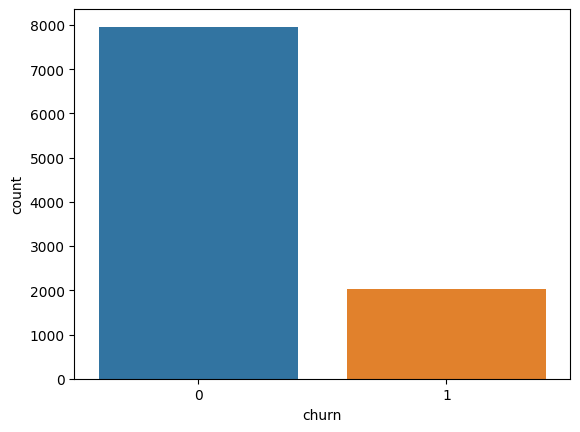

In [ ]:
sns.countplot(x = "churn", data = churn)

In [ ]:
churn_1 = churn[churn["churn"] == 1]
churn_0 = churn[churn["churn"] == 0]

In [ ]:
churn_1

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
16,15737452,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9981,15672754,498,Germany,Male,42,3,152039.70,1,1,1,53445.17,1
9982,15768163,655,Germany,Female,46,7,137145.12,1,1,0,115146.40,1
9991,15769959,597,France,Female,53,4,88381.21,1,1,0,69384.71,1
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1


In [ ]:
set(churn["tenure"])

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}

In [ ]:
churn_1.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,2.037000e+03,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.0
mean,1.569005e+07,645.351497,44.837997,4.932744,91108.539337,1.475209,0.699067,0.360825,101465.677531,1.0
std,7.269262e+04,100.321503,9.761562,2.936106,58360.794816,0.801521,0.458776,0.480358,57912.418071,0.0
min,1.556571e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,1.0
25%,1.562736e+07,578.000000,38.000000,2.000000,38340.020000,1.000000,0.000000,0.000000,51907.720000,1.0
50%,1.568896e+07,646.000000,45.000000,5.000000,109349.290000,1.000000,1.000000,0.000000,102460.840000,1.0
75%,1.575309e+07,716.000000,51.000000,8.000000,131433.330000,2.000000,1.000000,1.000000,152422.910000,1.0
max,1.581566e+07,850.000000,84.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199808.100000,1.0


In [ ]:
churn_0.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,7.963000e+03,7963.000000,7963.000000,7963.000000,7963.000000,7963.000000,7963.000000,7963.000000,7963.000000,7963.0
mean,1.569117e+07,651.853196,37.408389,5.033279,72745.296779,1.544267,0.707146,0.554565,99738.391772,0.0
std,7.174423e+04,95.653837,10.125363,2.880658,62848.040701,0.509536,0.455101,0.497045,57405.586966,0.0
min,1.556570e+07,405.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,90.070000,0.0
25%,1.562882e+07,585.000000,31.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50783.490000,0.0
50%,1.569154e+07,653.000000,36.000000,5.000000,92072.680000,2.000000,1.000000,1.000000,99645.040000,0.0
75%,1.575335e+07,718.000000,41.000000,7.000000,126410.280000,2.000000,1.000000,1.000000,148609.955000,0.0
max,1.581569e+07,850.000000,92.000000,10.000000,221532.800000,3.000000,1.000000,1.000000,199992.480000,0.0


In [ ]:
churn.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [ ]:
def chi2_test(column, churn):
    contingency_table = pd.crosstab(column, churn)
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

    #print("Chi-Square statistic:", chi2_stat)
    #print("p-value:", p_value)
    #print("Degrees of Freedom:", dof)
    #print("Expected frequencies:\n", expected)

    # Interpretation
    alpha = 0.05  # significance level
    if p_value < alpha:
        print("Reject the null hypothesis. There is a significant association between the two variables." )
    else:
        print("Fail to reject the null hypothesis. There is no significant association between the two variables.")




x = ["country", "gender", "tenure", "products_number", "credit_card", "active_member"]
for column in x:
    print(column, "churn")
    chi2_test(churn[column], churn["churn"])


country churn
Reject the null hypothesis. There is a significant association between the two variables.
gender churn
Reject the null hypothesis. There is a significant association between the two variables.
tenure churn
Fail to reject the null hypothesis. There is no significant association between the two variables.
products_number churn
Reject the null hypothesis. There is a significant association between the two variables.
credit_card churn
Fail to reject the null hypothesis. There is no significant association between the two variables.
active_member churn
Reject the null hypothesis. There is a significant association between the two variables.


In [ ]:
def anova(column, churn):
    f_statistic, p_value = f_oneway(column, churn)

    #print("F-statistic:", f_statistic)
    #print("P-value:", p_value)

    # Interpret the result
    alpha = 0.05  # Common significance level (5%)

    if p_value < alpha:
        print("There is a statistically significant difference among the groups.")
    else:
        print("There is no statistically significant difference among the groups.")


x = ["credit_score",  "age", "balance",  "estimated_salary"]
for column in x:
    print(column, "churn")
    anova(churn[column], churn["churn"])


credit_score churn
There is a statistically significant difference among the groups.
age churn
There is a statistically significant difference among the groups.
balance churn
There is a statistically significant difference among the groups.
estimated_salary churn
There is a statistically significant difference among the groups.


In [ ]:
churn_new = pd.get_dummies(churn, columns = ['country', 'gender'])
churn_new

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,39,5,0.00,2,1,0,96270.64,0,1,0,0,0,1
9996,15569892,516,35,10,57369.61,1,1,1,101699.77,0,1,0,0,0,1
9997,15584532,709,36,7,0.00,1,0,1,42085.58,1,1,0,0,1,0
9998,15682355,772,42,3,75075.31,2,1,0,92888.52,1,0,1,0,0,1


In [ ]:
# train test split

x = churn_new.drop(columns = ["customer_id", "churn"])
y = churn_new["churn"]

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=7)

In [ ]:
# Grid Search CV

logistic_reg = LogisticRegression()
param_grid = {
    'penalty' : ['elasticnet', 'l1', 'l2', None],
    'C' : [0.7, 0.5],
    'solver':['saga']
}
gscv = GridSearchCV(estimator=logistic_reg, cv=5, param_grid = param_grid, verbose = 3)
gscv.fit(xtrain, ytrain)
print(gscv.best_params_)
print(gscv.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 2/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 3/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 4/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 5/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 1/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.797 total time=   0.0s


c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.797 total time=   0.0s
[CV 3/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.797 total time=   0.1s


c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 4/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.797 total time=   0.0s
[CV 5/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.796 total time=   0.0s


...

c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


[CV 3/5] END ..C=0.5, penalty=None, solver=saga;, score=0.797 total time=   0.1s
[CV 4/5] END ..C=0.5, penalty=None, solver=saga;, score=0.797 total time=   0.1s


c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
10 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the followin

[CV 5/5] END ..C=0.5, penalty=None, solver=saga;, score=0.796 total time=   0.1s
{'C': 0.7, 'penalty': 'l1', 'solver': 'saga'}
0.7967500000000001


c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
logistic_reg = LogisticRegression(C = 0.7, penalty = 'l1', solver = 'saga')
logistic_reg.fit(xtrain, ytrain)

c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=0.7, penalty='l1', solver='saga')

In [ ]:
ytrain_predict = logistic_reg.predict(xtrain)
ytest_predict = logistic_reg.predict(xtest)

print("train accuracy : ", accuracy_score(ytrain, ytrain_predict))
print("test accuracy : ", accuracy_score(ytest, ytest_predict))

train accuracy :  0.79675
test accuracy :  0.7945


In [ ]:
print(classification_report(ytest, ytest_predict))
print("auc score", roc_auc_score(ytest, ytest_predict))

              precision    recall  f1-score   support

           0       0.79      1.00      0.89      1589
           1       0.00      0.00      0.00       411

    accuracy                           0.79      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.79      0.70      2000

auc score 0.5


c:\users\dev\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\dev\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\dev\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
churn_new

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,39,5,0.00,2,1,0,96270.64,0,1,0,0,0,1
9996,15569892,516,35,10,57369.61,1,1,1,101699.77,0,1,0,0,0,1
9997,15584532,709,36,7,0.00,1,0,1,42085.58,1,1,0,0,1,0
9998,15682355,772,42,3,75075.31,2,1,0,92888.52,1,0,1,0,0,1


In [ ]:
x = churn_new.drop(columns = ["customer_id", "credit_score", "age", "tenure", "balance", "credit_card", "estimated_salary", "churn"])
y = churn_new["churn"]


xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=7)

In [ ]:
# Grid Search CV

logistic_reg = LogisticRegression()
param_grid = {
    'penalty' : ['elasticnet', 'l1', 'l2', None],
    'C' : [0.7, 0.5],
    'solver':['saga']
}
gscv = GridSearchCV(estimator=logistic_reg, cv=5, param_grid = param_grid, verbose = 3)
gscv.fit(xtrain, ytrain)
print(gscv.best_params_)
print(gscv.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 2/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 3/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 4/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 5/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 1/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.797 total time=   0.0s
[CV 2/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.797 total time=   0.0s
[CV 3/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.797 total time=   0.0s
[CV 4/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.797 total time=   0.0s
[CV 5/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.796 total time=   0.0s
[CV 1/5] END ....C=0.7, penalty=l2, solver=saga;, score=0.797 total time=   0.0s
[CV 2/5] END ....C=0.7, penalty=l2, sol

c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


[CV 5/5] END ..C=0.7, penalty=None, solver=saga;, score=0.796 total time=   0.0s
[CV 1/5] END C=0.5, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 2/5] END C=0.5, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 3/5] END C=0.5, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 4/5] END C=0.5, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 5/5] END C=0.5, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 1/5] END ....C=0.5, penalty=l1, solver=saga;, score=0.797 total time=   0.0s
[CV 2/5] END ....C=0.5, penalty=l1, solver=saga;, score=0.797 total time=   0.0s
[CV 3/5] END ....C=0.5, penalty=l1, solver=saga;, score=0.797 total time=   0.0s
[CV 4/5] END ....C=0.5, penalty=l1, solver=saga;, score=0.797 total time=   0.0s
[CV 5/5] END ....C=0.5, penalty=l1, solver=saga;, score=0.796 total time=   0.0s
[CV 1/5] END ....C=0.5, penalty=l2, solver=saga;, score=0.797 total time=   0.0s
[CV 2/5] END ....C

c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
10 fits failed out of a to

In [ ]:
logistic_reg = LogisticRegression(C = 0.7, penalty = 'l1', solver = 'saga')
logistic_reg.fit(xtrain, ytrain)

LogisticRegression(C=0.7, penalty='l1', solver='saga')

In [ ]:
ytrain_predict = logistic_reg.predict(xtrain)
ytest_predict = logistic_reg.predict(xtest)

print("train accuracy : ", accuracy_score(ytrain, ytrain_predict))
print("test accuracy : ", accuracy_score(ytest, ytest_predict))

train accuracy :  0.79675
test accuracy :  0.7945


In [ ]:
print(classification_report(ytest, ytest_predict))
print("auc score", roc_auc_score(ytest, ytest_predict))

              precision    recall  f1-score   support

           0       0.79      1.00      0.89      1589
           1       0.00      0.00      0.00       411

    accuracy                           0.79      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.79      0.70      2000

auc score 0.5


c:\users\dev\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\dev\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\dev\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
churn_new_0 = churn_new[churn_new["churn"] == 0]
churn_new_0

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0
6,15592531,822,50,7,0.00,2,1,1,10062.80,0,1,0,0,0,1
8,15792365,501,44,4,142051.07,2,0,1,74940.50,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9993,15569266,644,28,7,155060.41,1,1,0,29179.52,0,1,0,0,0,1
9994,15719294,800,29,2,0.00,2,0,0,167773.55,0,1,0,0,1,0
9995,15606229,771,39,5,0.00,2,1,0,96270.64,0,1,0,0,0,1
9996,15569892,516,35,10,57369.61,1,1,1,101699.77,0,1,0,0,0,1


In [ ]:
churn_new_1 = churn_new[churn_new["churn"] == 1]
churn_new_1

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
5,15574012,645,44,8,113755.78,2,1,0,149756.71,1,0,0,1,0,1
7,15656148,376,29,4,115046.74,4,1,0,119346.88,1,0,1,0,1,0
16,15737452,653,58,1,132602.88,1,1,0,5097.67,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9981,15672754,498,42,3,152039.70,1,1,1,53445.17,1,0,1,0,0,1
9982,15768163,655,46,7,137145.12,1,1,0,115146.40,1,0,1,0,1,0
9991,15769959,597,53,4,88381.21,1,1,0,69384.71,1,1,0,0,1,0
9997,15584532,709,36,7,0.00,1,0,1,42085.58,1,1,0,0,1,0


In [ ]:
churn_new_0_sample = churn_new_0.sample(n = 2500)
churn_new_0_sample

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
6398,15591822,593,26,9,76226.90,1,1,0,167564.82,0,0,0,1,0,1
2884,15776047,620,29,3,0.00,2,0,1,153392.28,0,1,0,0,1,0
8889,15777046,580,39,9,128362.59,1,1,0,86044.98,0,1,0,0,1,0
1101,15782219,703,29,9,0.00,2,1,0,50679.48,0,0,0,1,0,1
5464,15795540,556,36,2,134208.22,1,0,1,177670.57,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6406,15637118,684,33,4,140700.61,1,1,0,103557.93,0,1,0,0,0,1
4221,15621064,701,23,5,186101.18,2,1,1,76611.33,0,0,1,0,0,1
6270,15702806,696,24,9,0.00,1,0,0,10883.52,0,0,0,1,0,1
4856,15721921,796,44,8,165326.20,1,1,1,57205.55,0,1,0,0,0,1


In [ ]:
churn_new_balanced = pd.concat([churn_new_0_sample, churn_new_1])
churn_new_balanced

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
6398,15591822,593,26,9,76226.90,1,1,0,167564.82,0,0,0,1,0,1
2884,15776047,620,29,3,0.00,2,0,1,153392.28,0,1,0,0,1,0
8889,15777046,580,39,9,128362.59,1,1,0,86044.98,0,1,0,0,1,0
1101,15782219,703,29,9,0.00,2,1,0,50679.48,0,0,0,1,0,1
5464,15795540,556,36,2,134208.22,1,0,1,177670.57,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9981,15672754,498,42,3,152039.70,1,1,1,53445.17,1,0,1,0,0,1
9982,15768163,655,46,7,137145.12,1,1,0,115146.40,1,0,1,0,1,0
9991,15769959,597,53,4,88381.21,1,1,0,69384.71,1,1,0,0,1,0
9997,15584532,709,36,7,0.00,1,0,1,42085.58,1,1,0,0,1,0


In [ ]:
x = churn_new_balanced.drop(columns = ["customer_id", "credit_score", "age", "tenure", "balance", "credit_card", "estimated_salary", "churn"])
y = churn_new_balanced["churn"]
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=7)

In [ ]:
# Grid Search CV

logistic_reg = LogisticRegression()
param_grid = {
    'penalty' : ['elasticnet', 'l1', 'l2', None],
    'C' : [0.7, 0.5],
    'solver':['saga']
}
gscv = GridSearchCV(estimator=logistic_reg, cv=5, param_grid = param_grid, verbose = 3)
gscv.fit(xtrain, ytrain)
print(gscv.best_params_)
print(gscv.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 2/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 3/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 4/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 5/5] END C=0.7, penalty=elasticnet, solver=saga;, score=nan total time=   0.0s
[CV 1/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.635 total time=   0.0s
[CV 2/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.618 total time=   0.0s
[CV 3/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.631 total time=   0.0s
[CV 4/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.603 total time=   0.0s
[CV 5/5] END ....C=0.7, penalty=l1, solver=saga;, score=0.650 total time=   0.0s
[CV 1/5] END ....C=0.7, penalty=l2, solver=saga;, score=0.635 total time=   0.0s
[CV 2/5] END ....C=0.7, penalty=l2, sol

c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


[CV 2/5] END ....C=0.5, penalty=l2, solver=saga;, score=0.618 total time=   0.0s
[CV 3/5] END ....C=0.5, penalty=l2, solver=saga;, score=0.631 total time=   0.0s
[CV 4/5] END ....C=0.5, penalty=l2, solver=saga;, score=0.603 total time=   0.0s
[CV 5/5] END ....C=0.5, penalty=l2, solver=saga;, score=0.650 total time=   0.0s
[CV 1/5] END ..C=0.5, penalty=None, solver=saga;, score=0.635 total time=   0.0s
[CV 2/5] END ..C=0.5, penalty=None, solver=saga;, score=0.618 total time=   0.0s
[CV 3/5] END ..C=0.5, penalty=None, solver=saga;, score=0.631 total time=   0.0s
[CV 4/5] END ..C=0.5, penalty=None, solver=saga;, score=0.603 total time=   0.0s
[CV 5/5] END ..C=0.5, penalty=None, solver=saga;, score=0.650 total time=   0.0s
{'C': 0.7, 'penalty': 'l1', 'solver': 'saga'}
0.6274516956397834


c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\users\dev\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
10 fits failed out of a to

In [ ]:
logistic_reg = LogisticRegression(C = 0.7, penalty = 'l1', solver = 'saga')
logistic_reg.fit(xtrain, ytrain)

ytrain_predict = logistic_reg.predict(xtrain)
ytest_predict = logistic_reg.predict(xtest)

print("train accuracy : ", accuracy_score(ytrain, ytrain_predict))
print("test accuracy : ", accuracy_score(ytest, ytest_predict))

train accuracy :  0.6409479195370625
test accuracy :  0.6255506607929515


In [ ]:
print(classification_report(ytest, ytest_predict))
print("auc score", roc_auc_score(ytest, ytest_predict))

              precision    recall  f1-score   support

           0       0.63      0.74      0.68       493
           1       0.61      0.49      0.54       415

    accuracy                           0.63       908
   macro avg       0.62      0.61      0.61       908
weighted avg       0.62      0.63      0.62       908

auc score 0.6145702485397981


In [ ]:
error = []
for i in range(1,100):
    knnc = KNeighborsClassifier(n_neighbors=i)
    knnc.fit(xtrain, ytrain)
    ytest_pred = knnc.predict(xtest)
    error.append(1-accuracy_score(ytest, ytest_pred))

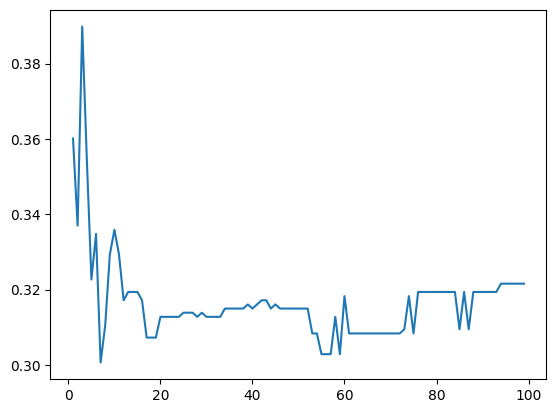

In [ ]:
k = [i for i in range(1,100)]
plt.plot(k, error)

In [ ]:
knnc = KNeighborsClassifier(n_neighbors=5)
knnc.fit(xtrain, ytrain)
ytest_pred = knnc.predict(xtest)

In [ ]:
print(classification_report(ytest, ytest_pred))

              precision    recall  f1-score   support

           0       0.70      0.70      0.70       493
           1       0.65      0.65      0.65       415

    accuracy                           0.68       908
   macro avg       0.67      0.67      0.67       908
weighted avg       0.68      0.68      0.68       908



In [ ]:
knnc = KNeighborsClassifier(n_neighbors=7)
knnc.fit(xtrain, ytrain)
ytest_pred = knnc.predict(xtest)

In [ ]:
print(classification_report(ytest, ytest_pred))

              precision    recall  f1-score   support

           0       0.69      0.82      0.75       493
           1       0.72      0.56      0.63       415

    accuracy                           0.70       908
   macro avg       0.70      0.69      0.69       908
weighted avg       0.70      0.70      0.69       908



In [ ]:
knnc = KNeighborsClassifier(n_neighbors=9)
knnc.fit(xtrain, ytrain)
ytest_pred = knnc.predict(xtest)

In [ ]:
print(classification_report(ytest, ytest_pred))

              precision    recall  f1-score   support

           0       0.67      0.78      0.72       493
           1       0.67      0.54      0.60       415

    accuracy                           0.67       908
   macro avg       0.67      0.66      0.66       908
weighted avg       0.67      0.67      0.67       908

